# Slow farmer Kolmogorov equations for $N_w$ and $N_g$

In [2]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [3]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [4]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [5]:
R = 0.00888
K = 0.00772

## setting up system

In [6]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [7]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

In [8]:
def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

In [9]:
#s matrix elements

def s_ijkl(i, j, k, l, N, A):

    if i == k and j == l:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    elif i == k-1 and j == l:
        return growthRate(k-1, N, A)
    elif i == k+1 and j == l:
        return eatRate(k+1, N, A)*l/N
    elif i == k+1 and j == l-1:
        return eatRate(k+1, N, A)*(N-l+1)/N
    else:
        return 0

In [10]:
def sMatrix(N, A):
    s_matrix = np.zeros((A+1, N+1, A+1, N+1))
    for i in range(A+1):
        for j in range(N+1):
            for k in range(A+1):
                for l in range(N+1):
                    s_matrix[i,j,k,l] = s_ijkl(i, j, k, l, N, A)
    return s_matrix

In [11]:
def sFlatten(s):
    """accepts matrix of shape (A+1, N+1, A+1, N+1)
    reshape into matrix of shape ( (A+1)(N+1), (A+1)(N+1) )
    does not need N and A passed to it because dimensions can be grabbed
    from s.shape
    """

    #dim = (A+1)(N+1)
    dim = s.shape[0]*s.shape[1]

    #fortran order
    return np.reshape(s, (dim, dim), "f")

def qFlatten(q):
    """accepts matrix of shape (A+1, N+1)
    reshape into matrix of shape (A+1)*(N+1)
    """

    dim = q.shape[0]*q.shape[1]

    return np.reshape(q, (dim), "f")

def qExpand(q, N, A):
    """accepts q vector of shape (A+1)*(N+1)
    reshape into matrix (A+1, N+1)
    needs N and A passed to it
    """

    return np.reshape(q, (A+1, N+1), "f")

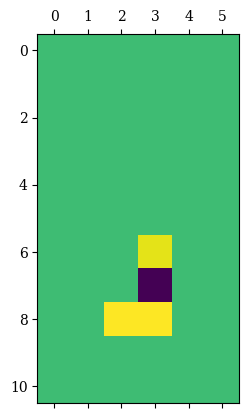

In [12]:
f, ax = plt.subplots()

ax.matshow(sMatrix(5, 10)[:, :, 7, 3])

## quasi-equilibrium distribution
used for initial condition for slow farmer

In [13]:
def quasiEqRec(A, N):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    #concatenate a zero to the beginning to represent p_0=0
    #important for use with pmfE() and pmfVar(), which assume that p_i appears at index i
    return np.concatenate((np.array([0]), np.linalg.solve(mat, b)))

## setting up simulation

In [14]:
with open("slow_sol_60.dat", "rb") as f:
    sol_60 = pickle.load(f)

with open("slow_sol_120.dat", "rb") as f:
    sol_120 = pickle.load(f)

## plot evolution of q
for A=100 and N=40, plot evolution of q

Text(0, 0.5, '$q_{x,y}$')

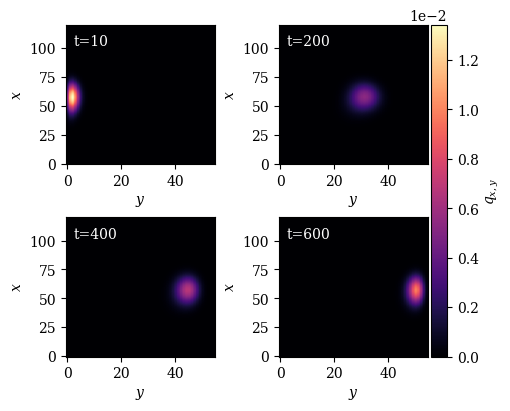

In [15]:
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(5, 4), layout="constrained")

axs = np.reshape(axs, 4)

n=54

data1 = qExpand(sol_120[str(n)]["y"][
                   :,timeToIndex(
                       sol_120[str(n)]["t"], 10)], n, 120)

data2 = qExpand(sol_120[str(n)]["y"][
                   :,timeToIndex(
                       sol_120[str(n)]["t"], 200)], n, 120)

data3 = qExpand(sol_120[str(n)]["y"][
                   :,timeToIndex(
                       sol_120[str(n)]["t"], 400)], n, 120)

data4 = qExpand(sol_120[str(n)]["y"][
                   :,timeToIndex(
                       sol_120[str(n)]["t"], 600)], n, 120)

#max q
#to use the same color scale in each image
vm = np.max([
    np.max(data1),
    np.max(data2),
    np.max(data3),
    np.max(data4)])

for i in range(0,4):
    ptr = axs[i].imshow([data1, data2, data3, data4][i],
                           origin="lower",
                           aspect="auto",
                           cmap="magma",
                           vmin=0, vmax=vm)

    #axs[i].set_xticks([0, 10, 20, 30, 40])
    axs[i].set_xlabel("$y$")
    axs[i].set_ylabel("$x$")
    axs[i].annotate("t={0}".format([10, 200, 400, 600][i]), (0.05, 0.85),
                    xycoords="axes fraction", color="white")

cb = plt.colorbar(ptr, ax=axs, orientation="vertical", pad=-0.05)
cb.formatter.set_powerlimits((-1, 5))
cb.ax.set_ylabel("$q_{x,y}$")

#plt.savefig("q_evolution.pdf")

## plot evolution of $\sum_{x}q_{x,y}$
i.e. the PMF of $N_w$, summed across all values of $N_g$

In [16]:
def nwpmf(qxy, N, A):
    """accept flattened bivariate pmf qxy, and N and A values
    unflatten qxy into (A+1)x(N+1) array and sum over the Ng axis"""
    return np.sum(qExpand(qxy, N, A), axis=0)

Text(0.83, 0.9, '(b)')

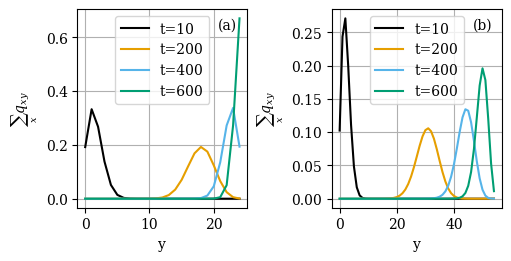

In [17]:
f, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained", figsize=(5, 2.5))

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

for i in [10, 200, 400, 600]:
    ax2.plot(nwpmf(sol_120["54"]["y"][:,timeToIndex(sol_120["60"]["t"], i)], 54, 120), label="t={0}".format(i))

for i in [10, 200, 400, 600]:
    ax1.plot(nwpmf(sol_120["24"]["y"][:,timeToIndex(sol_120["24"]["t"], i)], 24, 120), label="t={0}".format(i))

ax1.grid(True)
ax1.set_xlabel("y")
ax1.set_ylabel("$\sum_{x}q_{xy}$")
ax1.legend(loc="upper center")

ax2.grid(True)
ax2.set_xlabel("y")
ax2.set_ylabel("$\sum_{x}q_{xy}$")
ax2.legend(loc="upper center")

ax1.annotate("(a)", (0.83, 0.9), xycoords="axes fraction")
ax2.annotate("(b)", (0.83, 0.9), xycoords="axes fraction")

#plt.savefig("q_nw_evolution.pdf")

## F_slow plots

In [18]:
def expectedNw(qxy, N, A):
    """accept flattened bivariate pmf qxy, and N and A values
    calculate expected value of Nw by expanding qxy, summing over
    Ng axis, and finding expected value"""
    return pmfE(nwpmf(qxy, N, A))

def f_slow(soln, N, A, T):
    """soln: entire dict of sp.integrate.solve_ivp() output
    
    find expected Nw at time T, divide by T and return"""

    #need because for small T, soln may not actually have data at t close to T
    t_index = timeToIndex(soln["t"], T)

    return expectedNw(soln["y"][:,t_index], N, A)/soln["t"][t_index]

(0.5, 0.86, 0.0001, 0.00075)

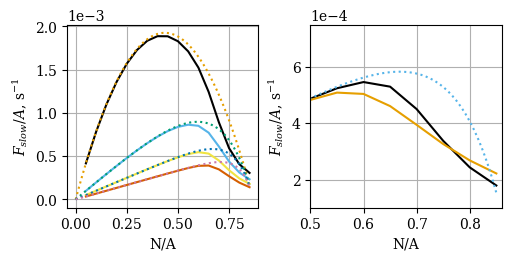

In [28]:
times = [1, 500, 1000, 1500]

f_slow_60 = {
    t: np.array([f_slow(
        sol_60[n], int(n), 60, t
    ) for n in sol_60.keys()]
               ) for t in times
}

f_slow_120 = {
    t: np.array([f_slow(
        sol_120[n], int(n), 120, t
    ) for n in sol_120.keys()]
               ) for t in times
}

f, (ax, ax2) = plt.subplots(ncols=2, layout="constrained", figsize=(5, 2.5))

ax.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

def fslow_det(N, A, T):
    """deterministic F_slow"""
    return (N-N*np.exp(-T*R+T*R*R*N/(A*K)))/T

for k in times:
    ax.plot(np.arange(6, 103, 6)/120, f_slow_120[k]/120, "-", label="T={0}".format(k))
    #ax.plot(np.arange(3, 52, 3)/60, f_slow_60[k]/60, "-")
    ax.plot(np.arange(0, 103)/120, fslow_det(np.arange(0, 103), 120, k)/120, ":")

#ax2.plot(np.arange(6, 103, 6)/120, f_slow_120[1]/120, "-", label="T=1")
#ax2.plot(np.arange(3, 52, 3)/60, f_slow_60[1]/60, "-")
#ax2.plot(np.arange(0, 103)/120, fslow_det(np.arange(0, 103), 120, 1)/120, ":")

ax2.plot(np.arange(6, 103, 6)/120, f_slow_120[1000]/120, "-", label="T=1000")
ax2.plot(np.arange(3, 52, 3)/60, f_slow_60[1000]/60, "-")
ax2.plot(np.arange(0, 103)/120, fslow_det(np.arange(0, 103), 120, 1000)/120, ":")

ax.grid(True)
ax.set_xlabel("N/A")
ax.set_ylabel("$F_{slow}/A$, s$^{-1}$")
ax.ticklabel_format(scilimits=(-2,5))

ax2.grid(True)
ax2.set_xlabel("N/A")
ax2.set_ylabel("$F_{slow}/A$, s$^{-1}$")
ax2.ticklabel_format(scilimits=(-2,5))
ax2.axis([0.5, 0.86, 0.0001, 0.00075])

(0.0, 100.0, 0.0, 100.0)

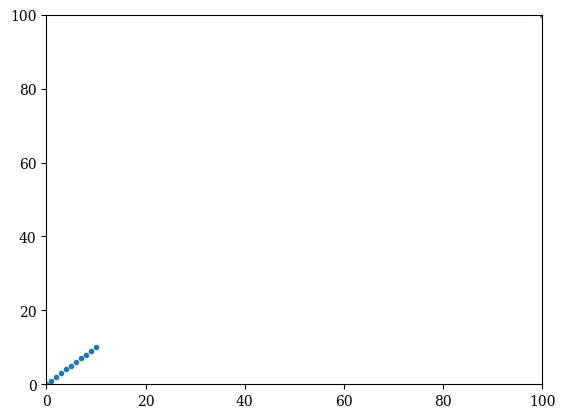

In [44]:
f, ax = plt.subplots()

ax.plot(sol_120["6"]["t"], sol_120["6"]["t"], ".")

ax.axis([0, 100, 0, 100])